In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [4]:
import json
import pandas as pd

ruta = "/home/zikocaklos/proyectos_mineria/nasa_neo_etl/data/raw/neo_raw.json"

with open(ruta, "r", encoding="utf-8") as file:
    data = json.load(file)

df = pd.DataFrame(data)

df.head()

,name,absolute_magnitude,diameter_min,diameter_max,diameter_avg,is_hazardous,velocity_kph,miss_distance_km
0,(2014 CE13),24.09,0.040416,0.090373,0.065395,False,60500.303027,3.434808e+06
1,(2016 CO246),25.80,0.018389,0.041119,0.029754,False,40223.154310,3.303107e+07
2,(2016 SZ1),26.30,0.014607,0.032662,0.023634,False,50344.139018,2.156626e+07
3,(2018 FD),24.27,0.037201,0.083184,0.060193,False,85167.239921,7.407618e+07
4,(2019 BV1),28.80,0.004619,0.010329,0.007474,False,99997.184389,6.926015e+07


In [5]:
print("Filas y columnas:", df.shape)

df.info()

Filas y columnas: (391, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 391 entries, 0 to 390
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   name                391 non-null    object 
 1   absolute_magnitude  391 non-null    float64
 2   diameter_min        391 non-null    float64
 3   diameter_max        391 non-null    float64
 4   diameter_avg        391 non-null    float64
 5   is_hazardous        391 non-null    bool   
 6   velocity_kph        391 non-null    float64
 7   miss_distance_km    391 non-null    float64
dtypes: bool(1), float64(6), object(1)
memory usage: 21.9+ KB


In [6]:
df.isnull().sum()

name                  0
absolute_magnitude    0
diameter_min          0
diameter_max          0
diameter_avg          0
is_hazardous          0
velocity_kph          0
miss_distance_km      0
dtype: int64

In [7]:
df["is_hazardous"].value_counts()

is_hazardous
False    352
True      39
Name: count, dtype: int64

In [8]:
df["is_hazardous"].value_counts(normalize=True) * 100

is_hazardous
False    90.025575
True      9.974425
Name: proportion, dtype: float64

In [9]:
df["is_hazardous"] = df["is_hazardous"].astype(int)

df[["name", "is_hazardous"]].head()

,name,is_hazardous
0,(2014 CE13),0
1,(2016 CO246),0
2,(2016 SZ1),0
3,(2018 FD),0
4,(2019 BV1),0


In [10]:
X = df[
    [
        "absolute_magnitude",
        "diameter_min",
        "diameter_max",
        "diameter_avg",
        "velocity_kph",
        "miss_distance_km"
    ]
]

y = df["is_hazardous"]

X.head()

,absolute_magnitude,diameter_min,diameter_max,diameter_avg,velocity_kph,miss_distance_km
0,24.09,0.040416,0.090373,0.065395,60500.303027,3.434808e+06
1,25.80,0.018389,0.041119,0.029754,40223.154310,3.303107e+07
2,26.30,0.014607,0.032662,0.023634,50344.139018,2.156626e+07
3,24.27,0.037201,0.083184,0.060193,85167.239921,7.407618e+07
4,28.80,0.004619,0.010329,0.007474,99997.184389,6.926015e+07


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)

Entrenamiento: (293, 6)
Prueba: (98, 6)


In [12]:
modelo_logistico = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(class_weight="balanced", random_state=42))
])

modelo_logistico.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not wo

In [13]:
y_pred_log = modelo_logistico.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1-score:", f1_score(y_test, y_pred_log))

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_log))

Accuracy: 0.8775510204081632
Precision: 0.45454545454545453
Recall: 1.0
F1-score: 0.625

Reporte de clasificación:
              precision    recall  f1-score   support

           0       1.00      0.86      0.93        88
           1       0.45      1.00      0.62        10

    accuracy                           0.88        98
   macro avg       0.73      0.93      0.78        98
weighted avg       0.94      0.88      0.90        98



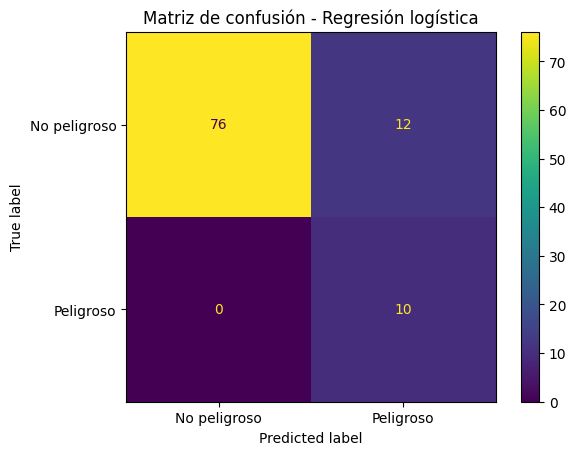

In [14]:
cm = confusion_matrix(y_test, y_pred_log)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No peligroso", "Peligroso"]
)

disp.plot()
plt.title("Matriz de confusión - Regresión logística")
plt.show()

In [15]:
modelo_rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

modelo_rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [16]:
y_pred_rf = modelo_rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1-score:", f1_score(y_test, y_pred_rf))

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.9183673469387755
Precision: 0.75
Recall: 0.3
F1-score: 0.42857142857142855

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.93      0.99      0.96        88
           1       0.75      0.30      0.43        10

    accuracy                           0.92        98
   macro avg       0.84      0.64      0.69        98
weighted avg       0.91      0.92      0.90        98



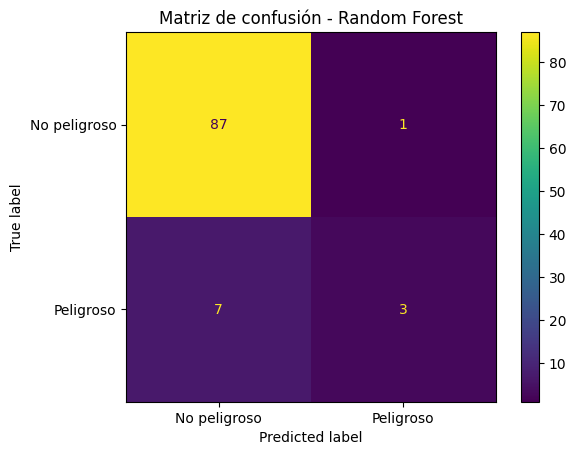

In [17]:
cm = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No peligroso", "Peligroso"]
)

disp.plot()
plt.title("Matriz de confusión - Random Forest")
plt.show()

In [18]:
importancias = pd.DataFrame({
    "variable": X.columns,
    "importancia": modelo_rf.feature_importances_
}).sort_values(by="importancia", ascending=False)

importancias

,variable,importancia
0,absolute_magnitude,0.276530
2,diameter_max,0.199384
3,diameter_avg,0.198833
1,diameter_min,0.196060
4,velocity_kph,0.072548
5,miss_distance_km,0.056645


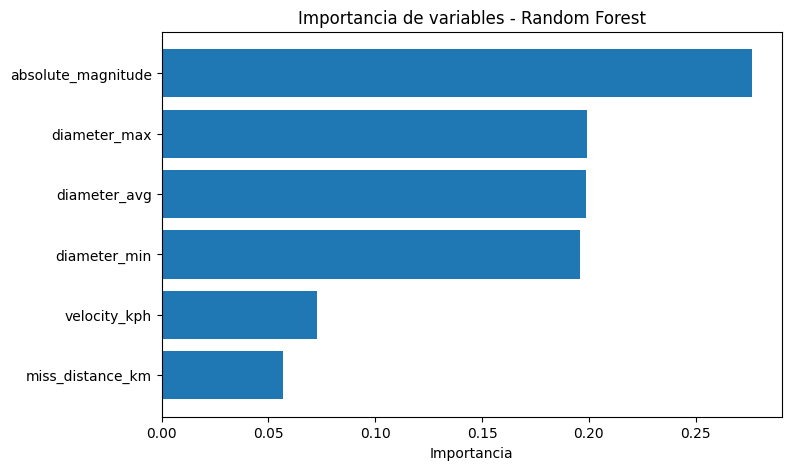

In [19]:
plt.figure(figsize=(8, 5))
plt.barh(importancias["variable"], importancias["importancia"])
plt.gca().invert_yaxis()
plt.title("Importancia de variables - Random Forest")
plt.xlabel("Importancia")
plt.show()